# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

In [8]:
# Cell 1: Import libraries and load the dataset

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("TempByCity.csv")


df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["AverageTemperatureUncertainty"] = pd.to_numeric(df["AverageTemperatureUncertainty"], errors="coerce")


df = df.dropna(subset=["dt", "AverageTemperature", "City", "Country", "Latitude", "Longitude"])


df["Year"] = df["dt"].dt.year

# Convert latitude/longitude from text like 10.45N / 87.34W into numeric values
def convert_lat_lon(value):
    value = str(value).strip()
    number = float(value[:-1])
    direction = value[-1]
    if direction in ["S", "W"]:
        return -number
    return number

df["Lat_num"] = df["Latitude"].apply(convert_lat_lon)
df["Lon_num"] = df["Longitude"].apply(convert_lat_lon)

df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year,Lat_num,Lon_num
0,1974-04-01,28.270,0.301,Kabankalan,Philippines,10.45N,123.55E,1974,10.45,123.55
1,1843-08-01,28.513,0.981,Baharampur,India,23.31N,88.25E,1843,23.31,88.25
2,1973-12-01,4.978,0.317,Jinhua,China,29.74N,120.00E,1973,29.74,120.00
3,1910-06-01,16.273,0.285,Kassel,Germany,50.63N,8.87E,1910,50.63,8.87
4,1803-10-01,11.933,3.018,Joliet,United States,40.99N,87.34W,1803,40.99,-87.34


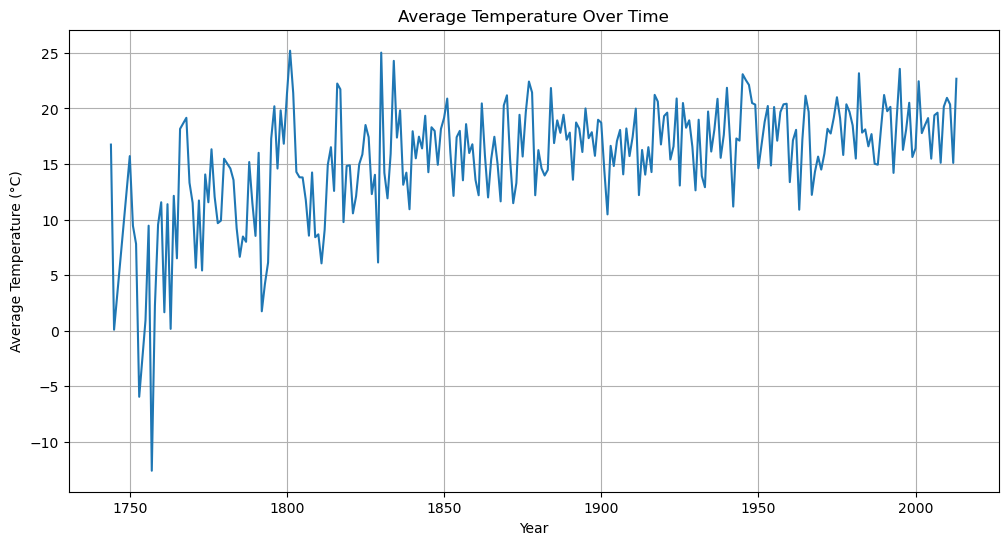

In [7]:


yearly_temp = df.groupby("Year")["AverageTemperature"].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_temp.index, yearly_temp.values)
plt.title("Average Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

## Dataset Description

For this assignment, I used the **TempByCity** dataset. This dataset came from **Kaggle** and includes temperature records for cities around the world collected over many years. I chose this dataset because it is both **spatial** and **time-series**, which makes it a good fit for studying how temperature changes across different places and across time.

The dataset has features such as **date (`dt`)**, **average temperature**, **temperature uncertainty**, **city**, **country**, **latitude**, and **longitude**. The date column makes it a time-series dataset because it lets us track changes over time, and the city, country, latitude, and longitude columns make it a spatial dataset because they show where the data was recorded.

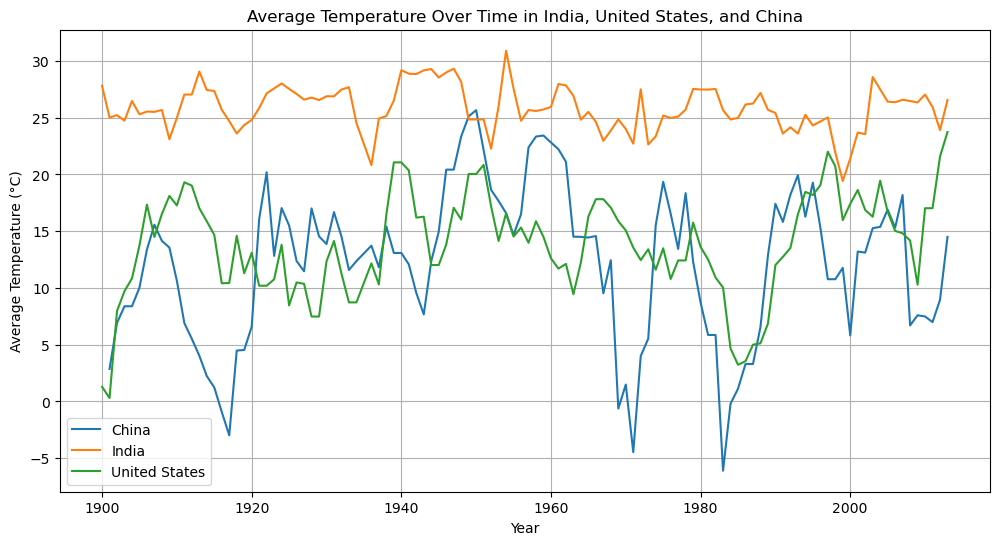

In [10]:
# Visualization 2 

top_countries = ["India", "United States", "China"]
country_df = df[df["Country"].isin(top_countries)].copy()


country_df = country_df[country_df["Year"] >= 1900]

country_yearly = country_df.groupby(["Year", "Country"])["AverageTemperature"].mean().unstack()


country_yearly_smooth = country_yearly.rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12, 6))
for country in country_yearly_smooth.columns:
    plt.plot(country_yearly_smooth.index, country_yearly_smooth[country], label=country)

plt.title("Average Temperature Over Time in India, United States, and China")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

## Visualization 2: Average Temperature Over Time in India, the United States, and China

This graph compares temperature changes over time in three different countries: India, the United States, and China. India stays warmer for most of the graph, while the United States and China are generally cooler, which shows that temperature patterns are different depending on location.

The graph also shows that each country changes differently over time. Even though all three countries have ups and downs, their lines do not match exactly, which suggests that both **time** and **space** affect temperature patterns.

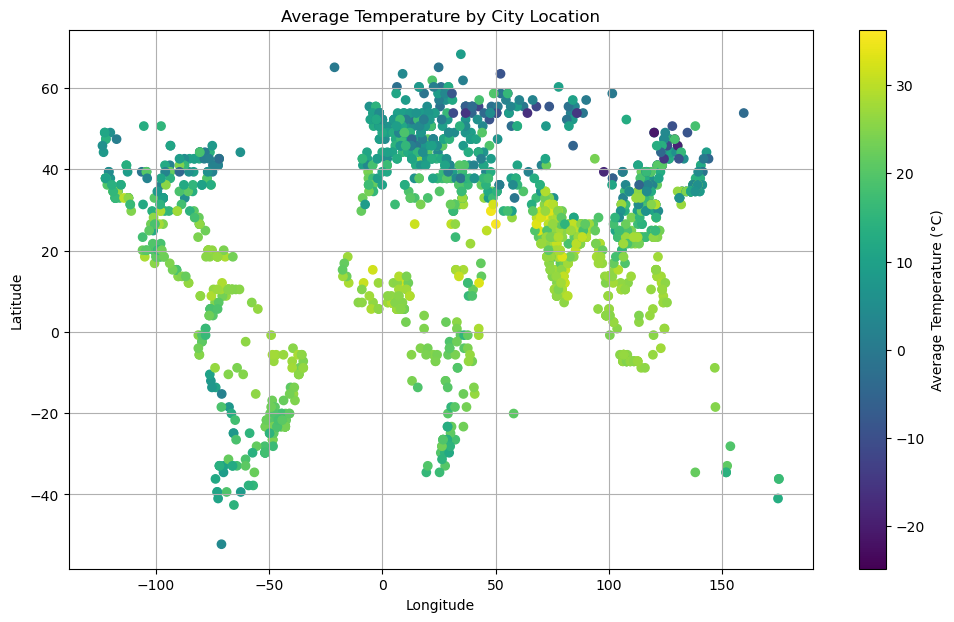

In [9]:
# Cell 7: Visualization 

city_temp = df.groupby(["City", "Country", "Lat_num", "Lon_num"])["AverageTemperature"].mean().reset_index()

plt.figure(figsize=(12, 7))
scatter = plt.scatter(city_temp["Lon_num"], city_temp["Lat_num"], c=city_temp["AverageTemperature"])
plt.colorbar(scatter, label="Average Temperature (°C)")
plt.title("Average Temperature by City Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

## Visualization 3: Average Temperature by City Location

This scatter plot shows how average temperature changes across different city locations using longitude and latitude. The colors show that some places are much warmer than others, and cities closer to certain parts of the world tend to have higher temperatures than cities in cooler regions.

Unlike the first graph, this visualization focuses more on spatial change than time change. It clearly shows that temperature is not the same everywhere, and that where a city is located has a strong effect on its climate.